# S6E10 — 00 EDA: Airline Passenger Satisfaction

**Dataset:** S6E10 Kaggle Playground Competition  
**Target:** `satisfaction` (True = satisfied, False = not satisfied)  
**Train size:** 699,635 rows | **Test size:** 299,844 rows

> **Pipeline position:** **00 EDA** → `01_baseline` → `02_features_experiments` → `03_final_features` → …

| | |
|---|---|
| **Goal** | Understand the data before modelling: quality, distributions, relation of every feature to the target, train/test consistency. Every finding is turned into a modelling decision (see the last section). |
| **Input** | `data/raw/train.csv`, `test.csv` |
| **Output** | none (insights only) |
| **Runtime** | ~1–2 min (the optional automated profile in section 4 is commented out) |

**Dataset in one paragraph:** a synthetic airline passenger survey generated from a real one (129,880 rows). 699,635 train / 299,844 test rows; 13 service ratings (1–5, sometimes 0), passenger and trip attributes, two delay columns; target `satisfaction` (44.4% satisfied).

**Sections:** 1 setup → 2 overview → 3 missing values → 4 automated report → 5 target → 6 distributions → 7 feature vs target → 8 correlations → 9 outliers → 10 train vs test → 11 summary → 12 open hypotheses → 13 effect sizes (Mann-Whitney) → 14 findings → decisions.

> **Glossary:** *MCAR* = missing completely at random (missingness unrelated to any value). *Distribution shift* = train and test differ, so CV would mislead. *Rank-biserial r* = effect size of the Mann-Whitney test, from −1 to +1; |r| > 0.3 strong, 0.1–0.3 medium.

## 1. Setup & Data Loading

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
from pathlib import Path
from matplotlib.ticker import FuncFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
millions = FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M")   # 1500000 -> 1.5M

# Colors: the first 3 are color-blind safe (validated).
# More than 3 categories: group the rest into "Other", or highlight one.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
GRAY = "#c3c2b7"
INK, MUTED, GRID = "#222222", "#52514e", "#e1e0d9"

sns.set_theme(style="white", palette=PALETTE, rc={
    "figure.figsize": (10, 4), "figure.dpi": 100,
    "font.sans-serif": ["Segoe UI", "Arial", "DejaVu Sans"],
    "date.converter": "concise",
    # title: left-aligned, bold (state the takeaway in it)
    "axes.titlelocation": "left", "axes.titleweight": "bold",
    "axes.titlesize": 13, "axes.titlepad": 14,
    # frame: no box, light horizontal grid only
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": GRAY, "axes.axisbelow": True,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    # quiet text, thicker lines, no legend frame
    "text.color": INK, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "lines.linewidth": 2, "legend.frameon": False,
})



def vgrid(ax):
    """Horizontal charts: vertical grid lines only."""
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)

print('Libraries loaded')

Libraries loaded


In [15]:
import os
DATA_DIR = Path('/kaggle/input/competitions/playground-series-s6e10') if os.path.exists('/kaggle/input') else next((p for p in (Path('data/raw'), Path('../data/raw')) if p.exists()), Path('data/raw'))

# Paths: Kaggle input, ../data/raw (when run from a subfolder) or data/raw.
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

print(train.shape)
print(test.shape)

(699635, 23)
(299844, 22)


## 2. Data Overview

In [16]:
df = train.copy(deep = True)

# Quick diagnostics: shape, duplicates, missing values
print('=' * 50)
print(f'  Rows       : {df.shape[0]:,}')
print(f'  Columns    : {df.shape[1]}')
print(f'  Duplicates : {df.duplicated().sum()}')
print(f'  Nulls      : {df.isna().sum().sum()}')
print(f'  Memory     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print('=' * 50)

pd.DataFrame({
    'dtype'   : df.dtypes,
    'non-null': df.count(),
    'unique'  : df.nunique(),
}).style.set_caption('Column Summary')

  Rows       : 699,635
  Columns    : 23
  Duplicates : 0
  Nulls      : 292
  Memory     : 266.7 MB


,dtype,non-null,unique
id,int64,699635,699635
Age,int64,699635,75
Flight Distance,int64,699635,3474
Inflight wifi service,int64,699635,6
Departure/Arrival time convenient,int64,699635,6
Ease of Online booking,int64,699635,6
Gate location,int64,699635,6
Food and drink,int64,699635,6
Online boarding,int64,699635,6
Seat comfort,int64,699635,6


In [17]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.sample(10)

,id,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,gender,customer_type,type_of_travel,class,satisfaction
45933,45933,41,643,5,5,5,5,4,5,5,5,5,5,5,3,4,0,0.000,Female,Loyal Customer,Business travel,Business,True
183437,183437,42,2988,2,4,4,4,2,3,4,2,2,2,2,2,4,0,0.000,Female,Loyal Customer,Business travel,Business,False
350011,350011,46,3200,2,2,2,2,5,4,5,4,4,4,4,3,3,0,0.000,Male,Loyal Customer,Business travel,Business,True
666946,666946,22,542,2,1,2,2,5,2,5,5,1,2,2,1,5,0,1.000,Female,disloyal Customer,Business travel,Eco,False
131014,131014,20,761,2,2,1,3,5,2,5,5,3,4,3,3,5,0,0.000,Male,disloyal Customer,Business travel,Eco,False
344308,344308,45,628,2,4,2,3,1,4,4,2,2,2,2,3,3,0,0.000,Male,Loyal Customer,Personal Travel,Business,False
331113,331113,47,1371,5,2,2,2,3,4,2,5,5,5,5,3,3,0,0.000,Female,Loyal Customer,Business travel,Eco,True
243271,243271,61,469,2,5,2,5,3,2,2,3,4,5,4,4,3,0,0.000,Male,Loyal Customer,Personal Travel,Eco,False
145956,145956,52,3698,1,1,1,1,5,5,4,5,5,5,4,4,3,0,0.000,Female,Loyal Customer,Business travel,Business,True
197816,197816,45,679,1,2,2,2,1,1,1,1,2,2,4,2,1,0,0.000,Male,Loyal Customer,Business travel,Eco,True


> Dataset has no duplicates. 292 nulls found — all in `arrival_delay_in_minutes` (~0.04% of rows).

## 3. Missing Values

Only `arrival_delay_in_minutes` contains 292 NaN values. Investigation below.

In [18]:
df['arrival_delay_in_minutes'].isna().value_counts()

arrival_delay_in_minutes
False    699343
True        292
Name: count, dtype: int64

In [19]:
df.loc[df['arrival_delay_in_minutes'].isna()].sample(10)

,id,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,gender,customer_type,type_of_travel,class,satisfaction
342367,342367,52,1076,5,2,2,2,5,5,4,5,5,2,2,1,5,30,NaN,Male,Loyal Customer,Business travel,Eco,True
148274,148274,38,447,3,4,3,5,4,3,4,4,5,5,4,4,4,42,NaN,Female,Loyal Customer,Personal Travel,Eco,True
383797,383797,25,1739,1,4,1,2,2,1,2,2,4,5,5,5,2,0,NaN,Female,Loyal Customer,Personal Travel,Eco,False
298845,298845,25,2615,4,4,4,4,3,3,3,3,5,5,5,4,3,0,NaN,Male,Loyal Customer,Business travel,Business,True
656266,656266,49,1074,1,1,1,4,5,1,5,5,4,1,3,4,5,0,NaN,Male,disloyal Customer,Business travel,Eco,True
535147,535147,30,2134,4,4,4,4,5,5,5,4,3,2,4,4,5,0,NaN,Male,Loyal Customer,Business travel,Business,True
108012,108012,20,552,3,0,3,5,2,3,2,2,5,5,4,5,2,4,NaN,Male,disloyal Customer,Business travel,Eco,False
456144,456144,59,1727,2,5,5,5,3,4,3,2,2,2,2,1,3,0,NaN,Male,Loyal Customer,Business travel,Business,False
461115,461115,41,356,3,4,3,4,3,3,3,3,3,3,5,4,3,0,NaN,Female,Loyal Customer,Personal Travel,Eco,False
525389,525389,27,522,4,4,4,4,5,5,5,5,3,2,2,3,5,15,NaN,Male,Loyal Customer,Business travel,Business,True


In [20]:
mask = df['arrival_delay_in_minutes'].isna()
print(df[mask]['departure_delay_in_minutes'].describe())
print(df[mask]['satisfaction'].value_counts())


count   292.000
mean      7.435
std      22.602
min       0.000
25%       0.000
50%       0.000
75%       1.000
max     202.000
Name: departure_delay_in_minutes, dtype: float64
satisfaction
False    186
True     106
Name: count, dtype: int64


> **Finding:** Missing arrival delays are not systematic — some rows have departure delays up to 202 min with NaN arrival delay. Pattern is random (MCAR). Decision: fill with `departure_delay_in_minutes` to preserve signal.

In [21]:
# Decision from the missing-value analysis above: fill from departure delay (the two columns are ~0.97 correlated).
df['arrival_delay_in_minutes'] = df['arrival_delay_in_minutes'].fillna(
    df['departure_delay_in_minutes']
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 699635 non-null  int64  
 1   age                                699635 non-null  int64  
 2   flight_distance                    699635 non-null  int64  
 3   inflight_wifi_service              699635 non-null  int64  
 4   departure/arrival_time_convenient  699635 non-null  int64  
 5   ease_of_online_booking             699635 non-null  int64  
 6   gate_location                      699635 non-null  int64  
 7   food_and_drink                     699635 non-null  int64  
 8   online_boarding                    699635 non-null  int64  
 9   seat_comfort                       699635 non-null  int64  
 10  inflight_entertainment             699635 non-null  int64  
 11  on-board_service                   6996

## 4. Automated EDA Report

`ydata_profiling` provides a full interactive overview — distributions, correlations, alerts. Run when needed.

In [22]:
# from ydata_profiling import ProfileReport
# ProfileReport(df).to_notebook_iframe()  # full overview

# # import missingno as msno
# # msno.matrix(df)  # missing pattern visualization

# import phik
# df.phik_matrix()  # correlation for mixed categorical/numeric

## 5. Target Distribution

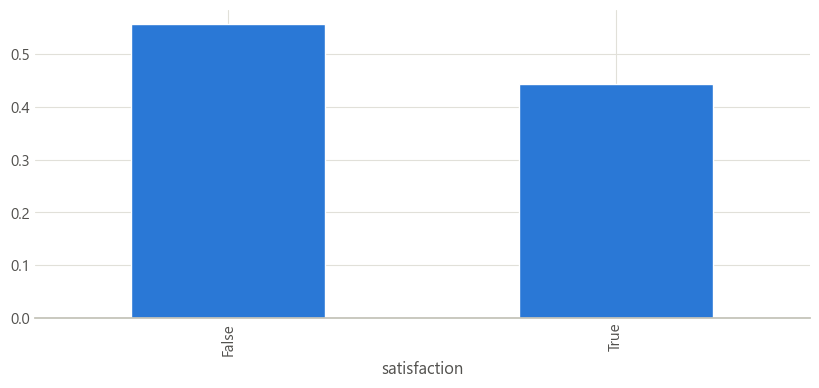

In [23]:
df['satisfaction'].value_counts(normalize=True).plot(kind='bar')
plt.show()


In [24]:
df['satisfaction'].value_counts(normalize=True)


satisfaction
False   0.556
True    0.444
Name: proportion, dtype: float64

> **Finding:** Mild class imbalance — 55.6% not satisfied vs 44.4% satisfied. Not critical; standard training without resampling should work. Monitor both class metrics (F1, recall) rather than accuracy alone.

## 6. Feature Distributions

### 6.1 Age

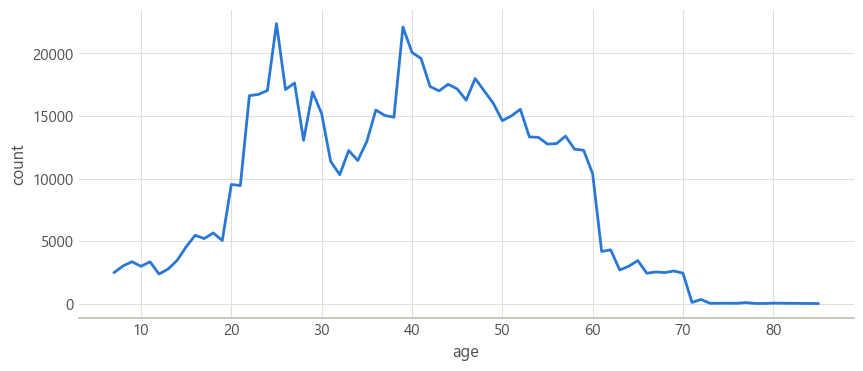

In [68]:
df['age'].value_counts().sort_index().plot(kind = 'line')
plt.xlabel('age')
plt.ylabel('count')
plt.show()

In [26]:
df['age_category'] = pd.cut(
    df['age'],
    bins = [0, 18, 30, 50, 60, 86],
    labels = ['<18', '18-30', '30-50', '50-60', '60+'],
    include_lowest = True
)

In [27]:
df['age_category'].value_counts().sort_index()

age_category
<18       44581
18-30    176701
30-50    316516
50-60    131087
60+       30750
Name: count, dtype: int64

> **Finding:** Age ranges from 7 to 85, median ~40. The largest group is 30–50 (45% of passengers). Very few minors (<18) — only 6.4% of data.

### 6.2 Flight Distance

In [28]:
df.loc[df['flight_distance'] > 5000].value_counts().sum()

np.int64(0)

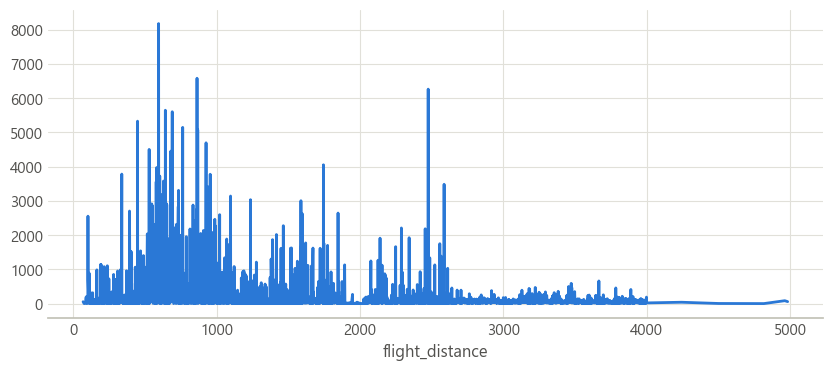

In [29]:
df['flight_distance'].value_counts().sort_index().plot(kind='line')
plt.show()


In [30]:
df['flight_distance_category'] = pd.cut(
    df['flight_distance'],
    bins  = [0, 1000, 2500, 5000],
    labels = ['short', 'medium', 'long'],
    include_lowest= True
)

In [31]:
df['flight_distance_category'].value_counts().sort_index()

flight_distance_category
short     372471
medium    221591
long      105573
Name: count, dtype: int64

> **Finding:** Most flights are short-haul (<1000 km, 53%). No flights exceed 5000 km. Distribution is right-skewed — long-haul flights are a minority but may carry strong satisfaction signal.

### 6.3 Delays

Only flights with delay > 0 shown (up to 100 min) to avoid the dominant zero spike.

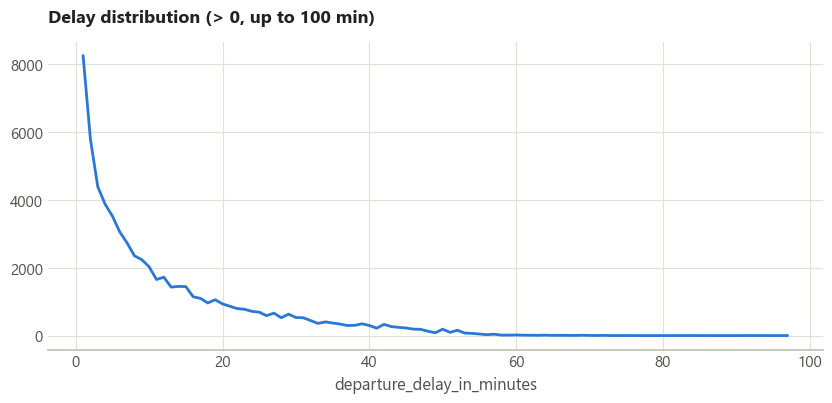

Flights without delay: 635,152
Flights with delay:    64,483


In [32]:
# departure_delayed
departure_delayed = df[df['departure_delay_in_minutes'] > 0]['departure_delay_in_minutes']
departure_delayed[departure_delayed <= 100].value_counts().sort_index().plot(kind='line')
plt.title('Delay distribution (> 0, up to 100 min)')
plt.show()

print(f'Flights without delay: {(df["departure_delay_in_minutes"] == 0).sum():,}')
print(f'Flights with delay:    {(df["departure_delay_in_minutes"] > 0).sum():,}')


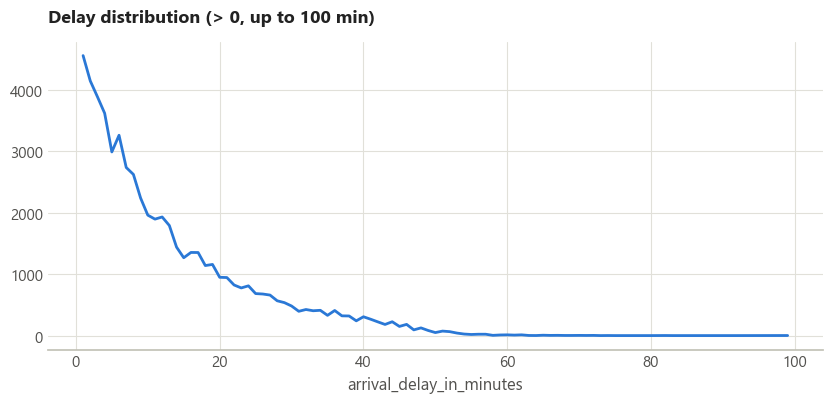

Flights without delay: 640,626
Flights with delay:    59,009


In [33]:
# arrival_delayed
arrival_delayed = df[df['arrival_delay_in_minutes'] > 0]['arrival_delay_in_minutes']
arrival_delayed[arrival_delayed <= 100].value_counts().sort_index().plot(kind='line')
plt.title('Delay distribution (> 0, up to 100 min)')
plt.show()

print(f'Flights without delay: {(df["arrival_delay_in_minutes"] == 0).sum():,}')
print(f'Flights with delay:    {(df["arrival_delay_in_minutes"] > 0).sum():,}')

> **Finding:** ~91% of flights have zero departure delay; ~92% have zero arrival delay. Among delayed flights, most delays are short (under 20 min). Extreme outliers exist (up to 500+ min) but are real data points, not errors.

## 7. Feature vs Target Correlations

### 7.1 Continuous Features

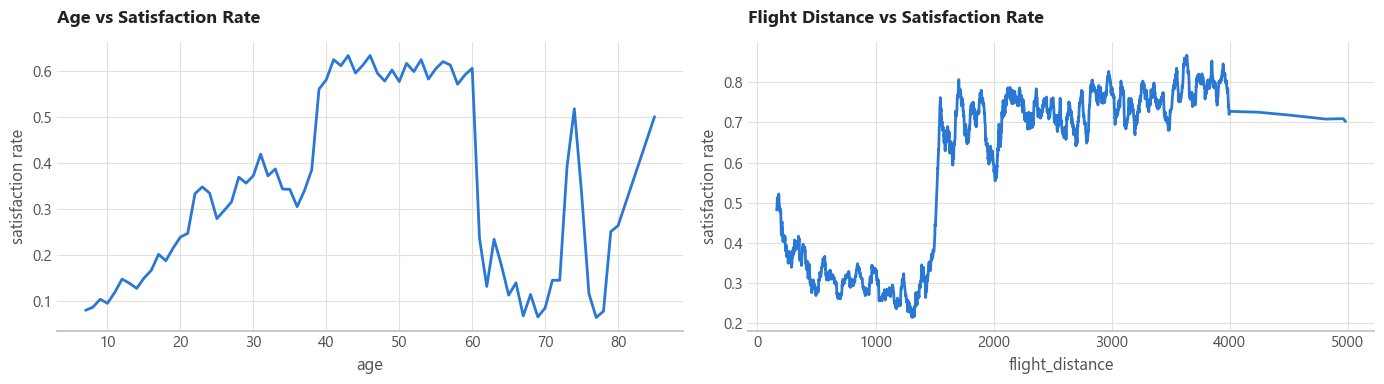

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# age vs satisfaction rate
df.groupby('age')['satisfaction'].mean().plot(ax=axes[0])
axes[0].set_title('Age vs Satisfaction Rate')
axes[0].set_ylabel('satisfaction rate')

# flight_distance vs satisfaction rate
df.groupby('flight_distance')['satisfaction'].mean().rolling(50).mean().plot(ax=axes[1])
axes[1].set_title('Flight Distance vs Satisfaction Rate')
axes[1].set_ylabel('satisfaction rate')

plt.tight_layout()
plt.show()


> **Finding:** Satisfaction rate increases with age — older passengers tend to be more satisfied. Flight distance shows a moderate positive trend — long-haul passengers are slightly more satisfied, likely due to Business class overlap.

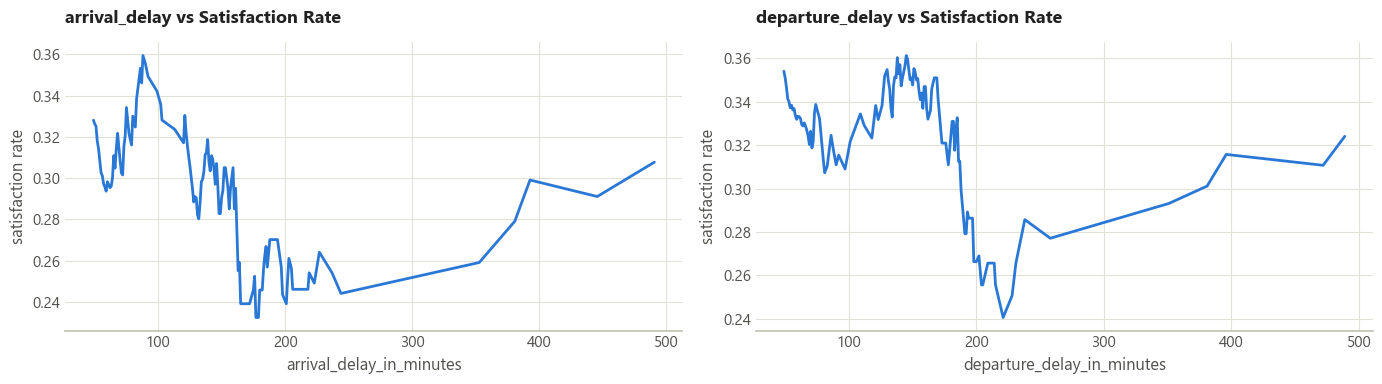

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# arrival_delayed vs satisfaction rate
df.groupby('arrival_delay_in_minutes')['satisfaction'].mean().rolling(50).mean().plot(ax=axes[0])
axes[0].set_title('arrival_delay vs Satisfaction Rate')
axes[0].set_ylabel('satisfaction rate')

# departure_delayed vs satisfaction rate
df.groupby('departure_delay_in_minutes')['satisfaction'].mean().rolling(50).mean().plot(ax=axes[1])
axes[1].set_title('departure_delay vs Satisfaction Rate')
axes[1].set_ylabel('satisfaction rate')

plt.tight_layout()
plt.show()


> **Finding:** Both delay features show a slight negative trend — longer delays correlate with lower satisfaction. However, the effect is moderate: even delayed flights can have satisfied passengers (Business class buffer).

### 7.2 Service Ratings (1–5 scale)

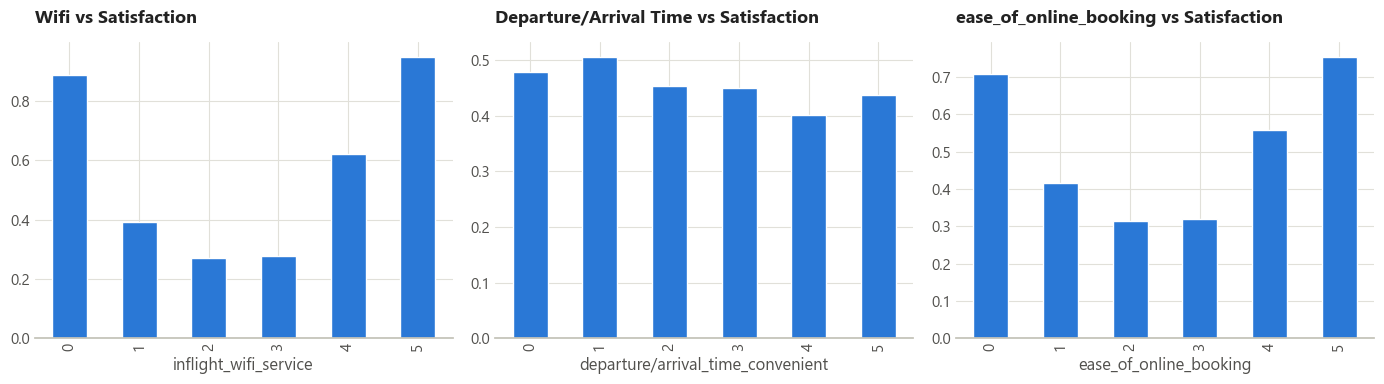

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('inflight_wifi_service')['satisfaction'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('Wifi vs Satisfaction')

df.groupby('departure/arrival_time_convenient')['satisfaction'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Departure/Arrival Time vs Satisfaction')

df.groupby('ease_of_online_booking')['satisfaction'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('ease_of_online_booking vs Satisfaction')

plt.tight_layout()
plt.show()


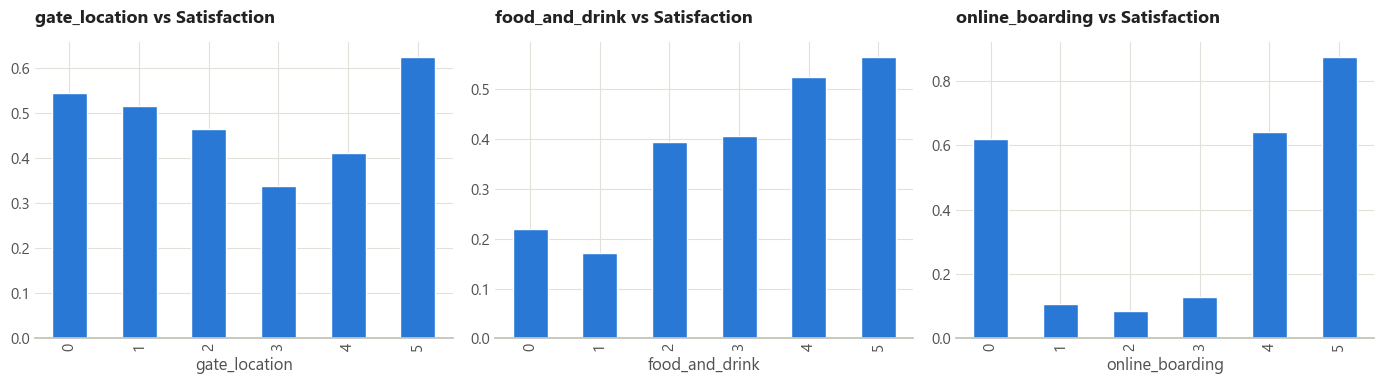

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('gate_location')['satisfaction'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('gate_location vs Satisfaction')

df.groupby('food_and_drink')['satisfaction'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('food_and_drink vs Satisfaction')

df.groupby('online_boarding')['satisfaction'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('online_boarding vs Satisfaction')

plt.tight_layout()
plt.show()


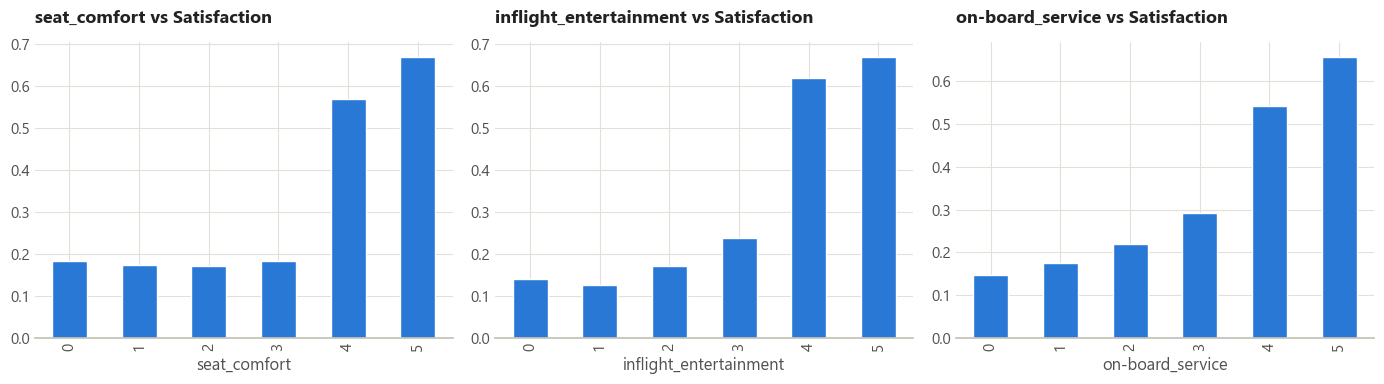

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('seat_comfort')['satisfaction'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('seat_comfort vs Satisfaction')

df.groupby('inflight_entertainment')['satisfaction'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('inflight_entertainment vs Satisfaction')

df.groupby('on-board_service')['satisfaction'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('on-board_service vs Satisfaction')

plt.tight_layout()
plt.show()


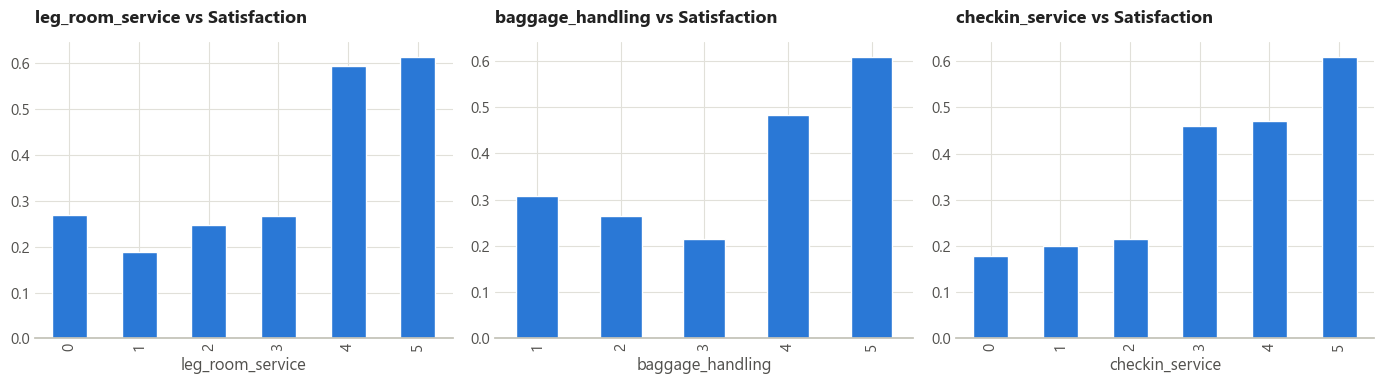

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df.groupby('leg_room_service')['satisfaction'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('leg_room_service vs Satisfaction')

df.groupby('baggage_handling')['satisfaction'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('baggage_handling vs Satisfaction')

df.groupby('checkin_service')['satisfaction'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('checkin_service vs Satisfaction')

plt.tight_layout()
plt.show()


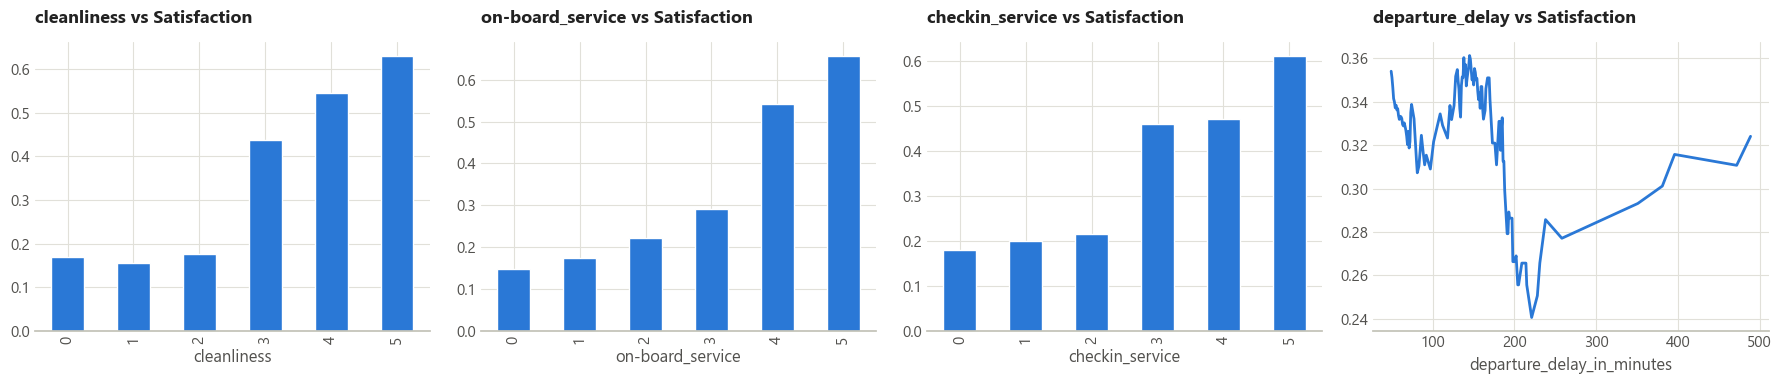

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

df.groupby('cleanliness')['satisfaction'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('cleanliness vs Satisfaction')

df.groupby('on-board_service')['satisfaction'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('on-board_service vs Satisfaction')

df.groupby('checkin_service')['satisfaction'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('checkin_service vs Satisfaction')

df.groupby('departure_delay_in_minutes')['satisfaction'].mean().rolling(50).mean().plot(ax=axes[3])
axes[3].set_title('departure_delay vs Satisfaction')

plt.tight_layout()
plt.show()

> **Finding:** All service ratings show a clear monotonic relationship with satisfaction — higher ratings consistently predict higher satisfaction. `online_boarding`, `inflight_entertainment`, and `seat_comfort` appear to have the steepest slopes, suggesting they are among the strongest predictors. Rating 0 (where present) behaves unusually — likely a missing-value substitute.

### 7.3 Categorical Features

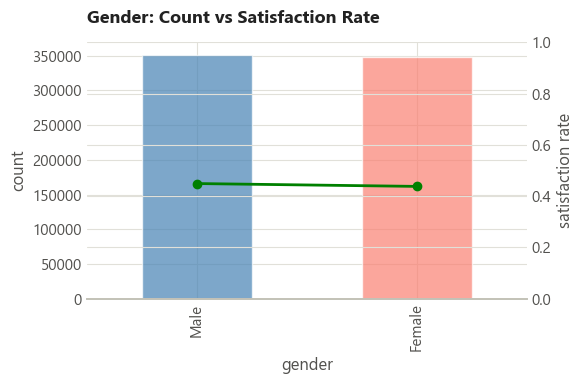

In [41]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# bar chart - counts
df['gender'].value_counts().plot(kind='bar', ax=ax1, color=['steelblue', 'salmon'], alpha=0.7)
ax1.set_ylabel('count')

# second axis - satisfaction rate
ax2 = ax1.twinx()
df.groupby('gender')['satisfaction'].mean().reindex(df['gender'].value_counts().index).plot(
    kind='line', ax=ax2, color='green', marker='o'
)
ax2.set_ylabel('satisfaction rate')
ax2.set_ylim(0, 1)

plt.title('Gender: Count vs Satisfaction Rate')
plt.tight_layout()
plt.show()


> **Finding:** Gender has minimal impact on satisfaction — nearly equal rates for Male and Female. Not likely to be a strong predictor.

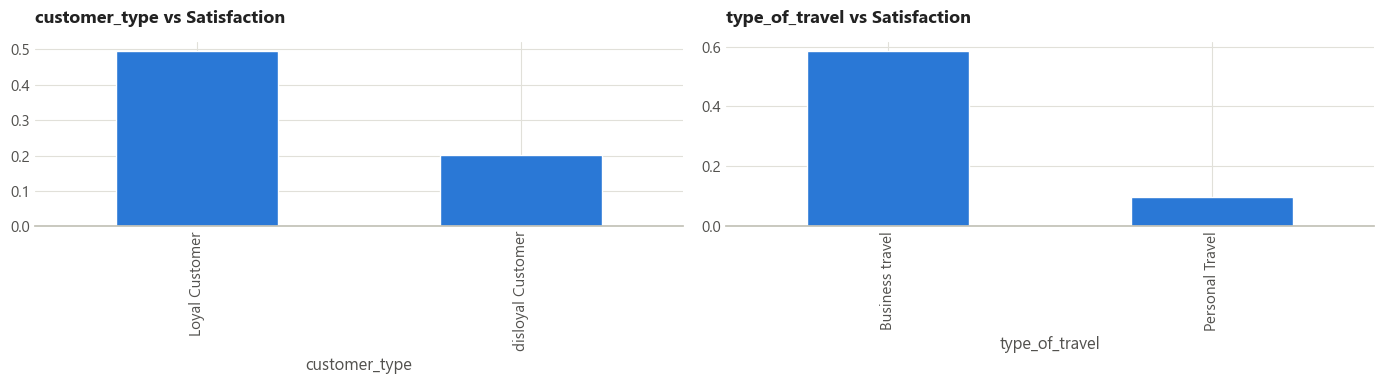

In [42]:
# Categorical features

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('customer_type')['satisfaction'].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('customer_type vs Satisfaction')

df.groupby('type_of_travel')['satisfaction'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('type_of_travel vs Satisfaction')

plt.tight_layout()
plt.show()


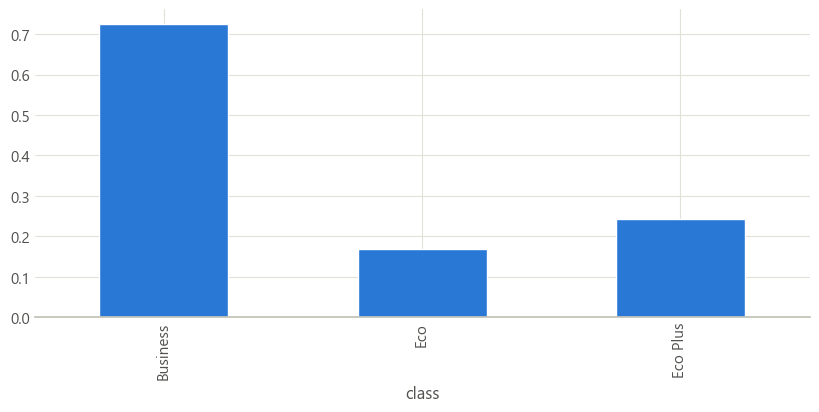

In [43]:
df.groupby('class')['satisfaction'].mean().plot(kind = 'bar')
plt.show()

> **Finding:** `type_of_travel` is a strong signal — Business travel passengers are significantly more satisfied than Personal travel. `class` is also strong — Business class has the highest satisfaction, Eco Plus surprisingly the lowest. `customer_type`: Loyal customers are more satisfied than disloyal.

### 7.4 Delay Bucket Analysis

Segmenting satisfaction rate by delay magnitude to reveal non-linear effects.

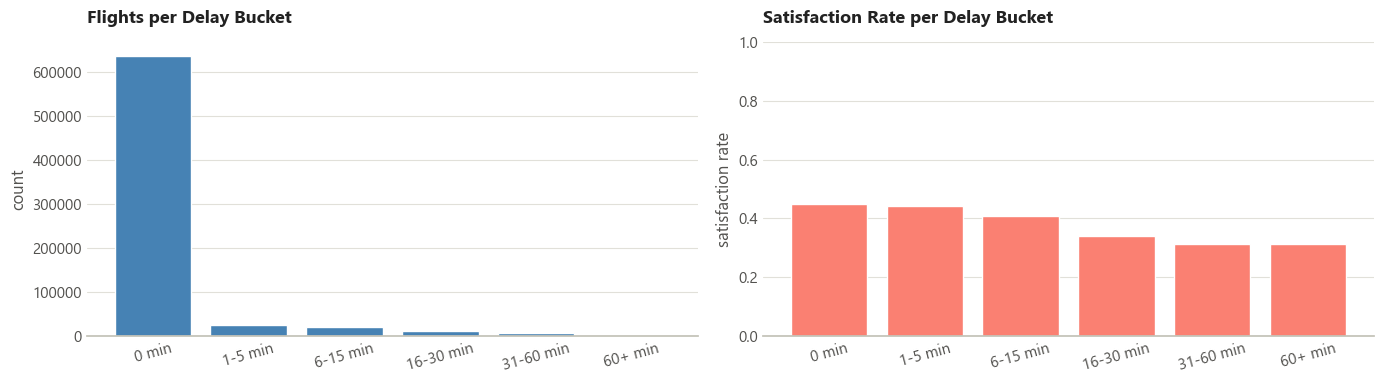

delay_bucket  count  satisfaction_rate
       0 min 635152              0.448
     1-5 min  25786              0.444
    6-15 min  20070              0.408
   16-30 min  11967              0.342
   31-60 min   6307              0.314
     60+ min    353              0.314


In [44]:
# Delay bucket analysis
df['delay_bucket'] = pd.cut(
    df['departure_delay_in_minutes'],
    bins=[-1, 0, 5, 15, 30, 60, 10000],
    labels=['0 min', '1-5 min', '6-15 min', '16-30 min', '31-60 min', '60+ min']
)

bucket_stats = df.groupby('delay_bucket', observed=True).agg(
    count=('satisfaction', 'count'),
    satisfaction_rate=('satisfaction', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(bucket_stats['delay_bucket'], bucket_stats['count'], color='steelblue')
axes[0].set_title('Flights per Delay Bucket')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(bucket_stats['delay_bucket'], bucket_stats['satisfaction_rate'], color='salmon')
axes[1].set_title('Satisfaction Rate per Delay Bucket')
axes[1].set_ylabel('satisfaction rate')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print(bucket_stats.to_string(index=False))

> **Finding:** Examine whether satisfaction drops sharply at a specific delay threshold (e.g. 30 min) rather than linearly. This informs whether to use raw delay or bucketized delay as a feature.

## 8. Feature Correlation Heatmap

Pearson correlations between all numeric features.

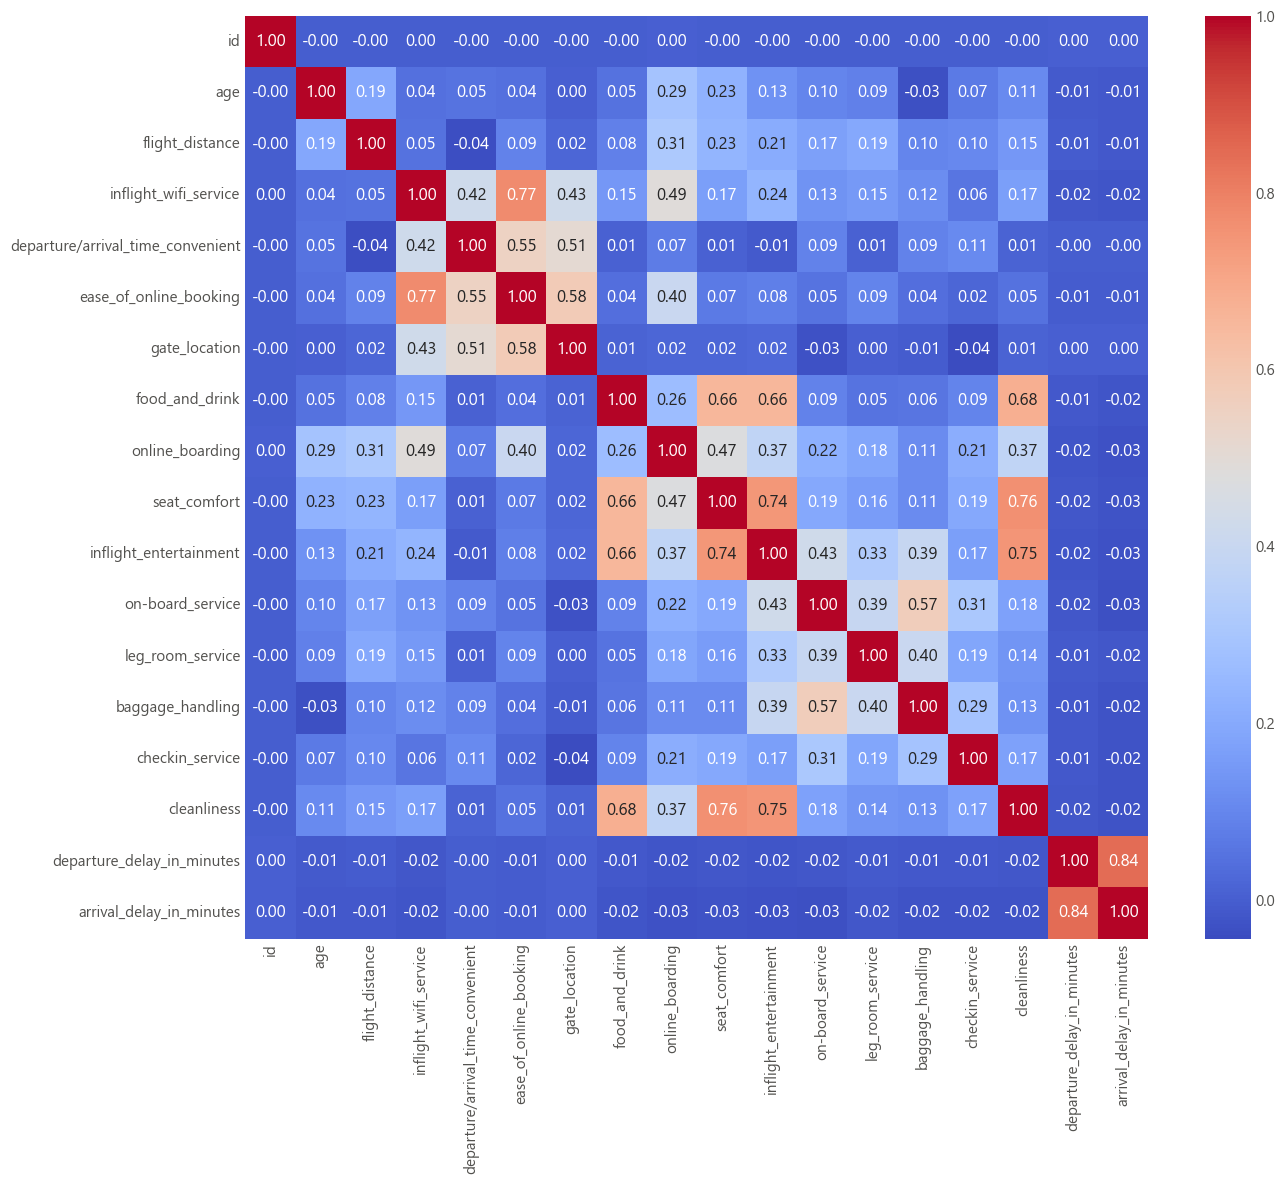

In [45]:
# Correlation between features
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
plt.tight_layout()


> **Finding:** `departure_delay_in_minutes` and `arrival_delay_in_minutes` are near-perfectly correlated (~0.97). One of them can be dropped or combined. Service ratings show low inter-correlation — they carry independent signal. `flight_distance` has weak correlation with delays.

## 9. Outlier Analysis

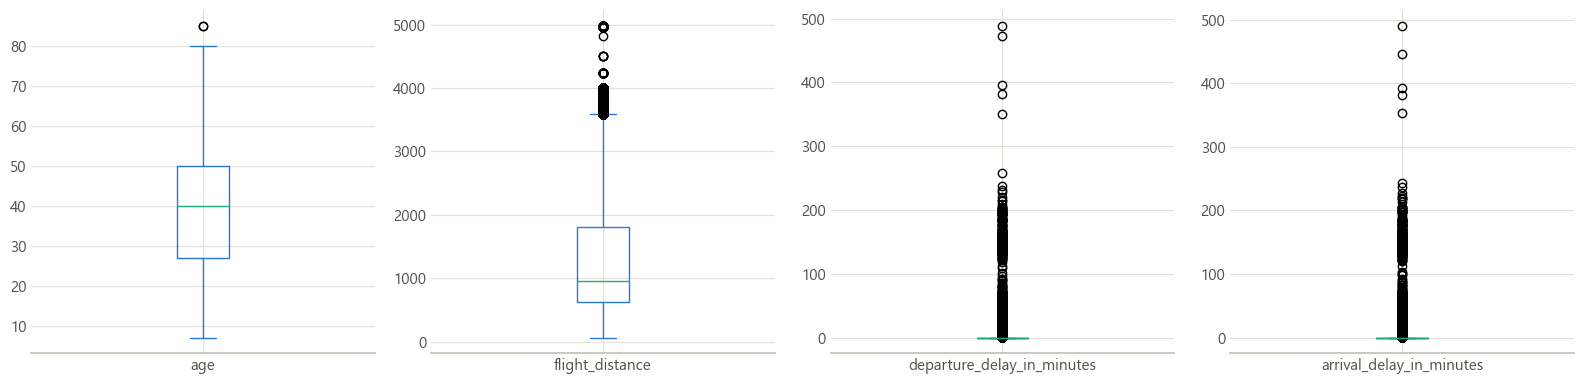

In [46]:
df[['age', 'flight_distance', 'departure_delay_in_minutes', 'arrival_delay_in_minutes']].plot(
    kind='box', subplots=True, layout=(1, 4), figsize=(16, 4)
)
plt.tight_layout()
plt.show()


> **Finding:** No data errors detected. Age has one point above 80 — valid. Flight distance has a few points above 4000 km — valid long-haul flights. Delay columns have heavy right tails (up to 500 min) — real extreme delays, not noise. No removal needed; consider log-transform for delay features during feature engineering.

## 10. Train vs Test Distribution

Checking for distribution shift — a common Kaggle pitfall.

### 10.1 Distribution comparison

In [47]:
test.columns = test.columns.str.lower().str.replace(' ', '_')

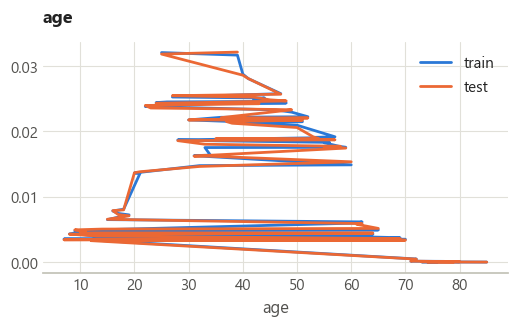

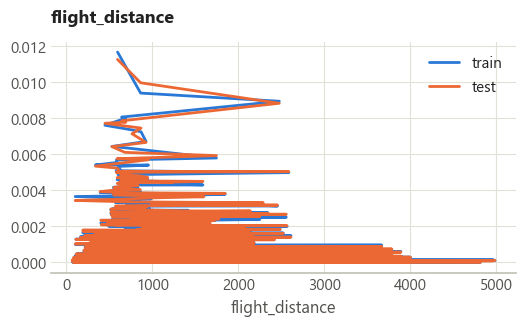

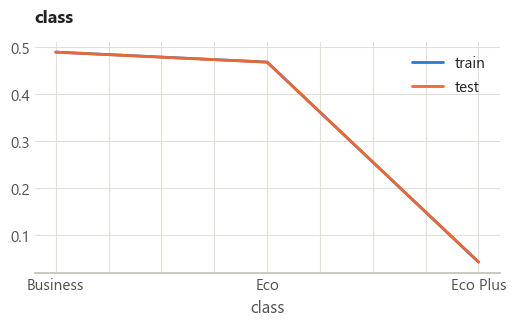

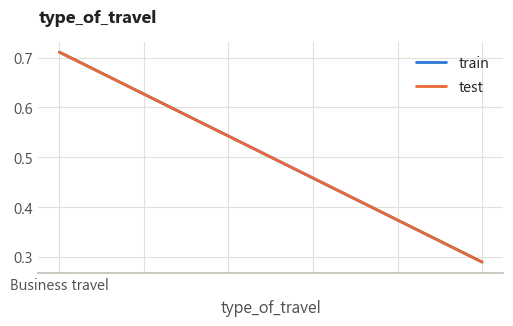

In [48]:
for col in ['age', 'flight_distance', 'class', 'type_of_travel']:
    fig, ax = plt.subplots(figsize=(6, 3))
    df[col].value_counts(normalize=True).plot(label='train', ax=ax)
    test[col].value_counts(normalize=True).plot(label='test', ax=ax)
    ax.legend()
    plt.title(col)
    plt.show()


> **Finding:** No distribution shift detected across all compared features (age, flight_distance, class, type_of_travel). Train and test distributions are nearly identical. Standard training without domain adaptation techniques is sufficient.

### 10.2 Target Sequence Stability Check

Verify that satisfaction rate is stable across row index — rules out row-order leakage or temporal drift in the synthetic dataset.

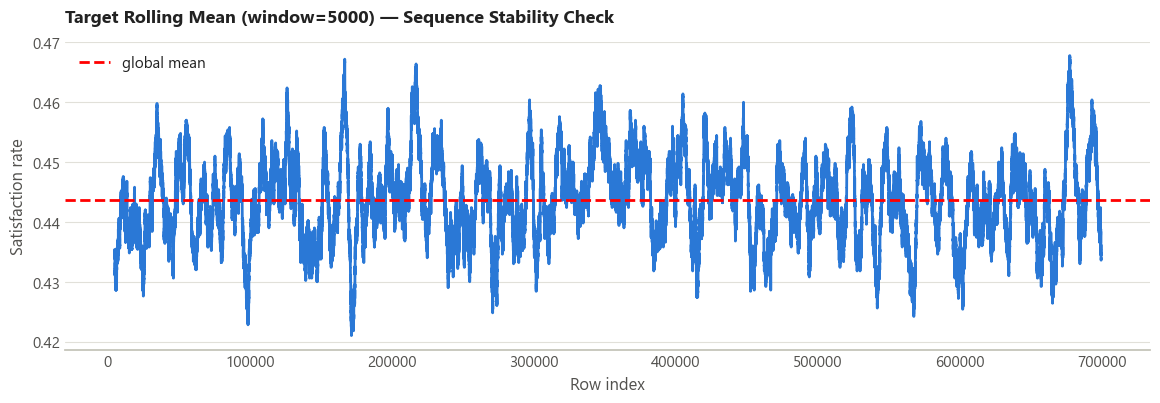

In [49]:
# Rolling mean over 5000 rows: a flat line means row order carries no information about the target.
window = 5000
rolling_mean = train['satisfaction'].astype(int).rolling(window).mean()

plt.figure(figsize=(14, 4))
plt.plot(rolling_mean)
plt.axhline(y=rolling_mean.mean(), color='r', linestyle='--', label='global mean')
plt.title('Target Rolling Mean (window=5000) — Sequence Stability Check')
plt.xlabel('Row index')
plt.ylabel('Satisfaction rate')
plt.legend()
plt.show()

> **Finding:** If the rolling mean stays flat around the global mean, there is no row-order signal or leakage. A trend would suggest the data was sorted by some feature correlated with the target.

## 11. Summary & Key Findings

### Dataset
- 699,635 train / 299,844 test rows, 22 features + target
- No duplicates, minimal missing values (292 NaN in `arrival_delay_in_minutes`, filled with departure delay)
- Mild class imbalance: 55.6% not satisfied / 44.4% satisfied

### Strongest Predictors (based on EDA)
| Feature | Direction | Notes |
|---|---|---|
| `type_of_travel` | Business travel → higher satisfaction | Likely the strongest single feature |
| `class` | Business > Eco > Eco Plus | Strong categorical signal |
| `online_boarding` | Higher rating → higher satisfaction | Steepest service slope |
| `inflight_entertainment` | Higher rating → higher satisfaction | |
| `seat_comfort` | Higher rating → higher satisfaction | |
| `customer_type` | Loyal → more satisfied | |
| `age` | Older → slightly more satisfied | |

### Weak / Redundant Features
- `gender` — near-zero impact on satisfaction
- `arrival_delay_in_minutes` — near-duplicate of `departure_delay_in_minutes` (corr ~0.97); consider dropping one
- `id` — should be dropped before modeling

### No Distribution Shift
Train and test distributions are identical → no adversarial validation needed.

---

## 12. Hypotheses & Open Questions for Feature Engineering

**1. Rating = 0 as hidden missing value**  
Some service columns contain rating = 0 (outside the 1–5 scale). Investigate whether these are genuine responses or missing data encoded differently. If systematic → create binary feature `has_zero_rating`. Decide: impute or keep as signal.

**2. Delay features are near-duplicate (corr ~0.97)**  
`arrival_delay_in_minutes` and `departure_delay_in_minutes` carry almost identical information. Options for feature engineering:
- Drop `arrival_delay_in_minutes` (simpler)
- Create `delay_diff = arrival_delay - departure_delay` as signal of unexpected in-flight delays

**3. Delay magnitude has non-linear effect on satisfaction**  
The correlation plot smooths over a likely threshold effect. Investigate bucket-level satisfaction rates:

| Delay bucket | Expected pattern |
|---|---|
| 0 min | Baseline satisfaction |
| 1–5 min | Minimal drop |
| 6–15 min | Moderate drop |
| 16–30 min | Stronger drop |
| 60+ min | Sharp drop |

Add delay bucket as categorical feature; may outperform raw delay value in tree models.

**4. Train/test drift check is incomplete**  
Currently only 4 features checked (age, flight_distance, class, type_of_travel). Extend to all numeric features — especially service ratings and delay columns — before finalizing the modeling pipeline.

**5. Business class + long flight interaction**  
Do long-haul Business passengers show disproportionately high satisfaction? Could create `is_business_long` feature.

**6. Young + Personal travel segment**  
Do young passengers on personal trips have the lowest satisfaction? Potential interaction feature.

**7. Service rating composite**  
Average of all service ratings as a single feature (`service_score_mean`) may outperform individual ones — test in feature engineering.

**8. Loyal customer + delay interaction**  
Do loyal customers tolerate delays better than disloyal ones? Could reduce delay's negative impact for that segment.

**9. Missing value flag as feature**  
292 rows had NaN in `arrival_delay_in_minutes`. These were filled with `departure_delay_in_minutes`, but the missingness itself may carry signal (cancelled flight, technical issue, data not recorded). Add binary feature:  
`arrival_delay_missing = 1` for originally missing rows, `0` otherwise.

**10. Feature family grouping for ablation**  
Group features by semantic meaning to test which family drives the most predictive power:

| Group | Features |
|---|---|
| Passenger context | `age`, `gender`, `customer_type`, `type_of_travel` |
| Trip context | `class`, `flight_distance` |
| Service ratings | `inflight_wifi_service`, `online_boarding`, `food_and_drink`, `seat_comfort`, `inflight_entertainment`, `on-board_service`, `leg_room_service`, `baggage_handling`, `checkin_service`, `cleanliness`, `gate_location`, `departure/arrival_time_convenient`, `ease_of_online_booking` |
| Operational delays | `departure_delay_in_minutes`, `arrival_delay_in_minutes` |

Train model with each group alone → identifies which family is most predictive.

## 13. Effect sizes: which features separate satisfied from unsatisfied passengers?
This block was added after the summary, to answer a practical question: *which feature has a stronger relation to the target?*

**Method — Mann-Whitney U test.** Compares the values of two groups (satisfied / not satisfied) without assuming a normal distribution. With 700 000 rows, **the p-value is always ≈ 0 and tells nothing**; what matters is the **effect size** (rank-biserial r).

**Reading r:** the U-statistic is computed for the *satisfied* group; r = 1 − 2U/(n₁n₂). Negative r means the satisfied group has the larger values. Rule of thumb: |r| < 0.1 weak, 0.1–0.3 medium, > 0.3 strong.

### 13.1 Flight distance vs satisfaction

H₀ (null): Flight distance is distributed identically for satisfied and dissatisfied passengers. There is no difference.

H₁ (alternative): Flight distance differs between the groups. Satisfied passengers fly farther (or a shorter distance)—the direction doesn't matter; we are simply testing whether a difference exists.

In [50]:
from scipy import stats
import numpy as np

In [51]:
satisfied = df.loc[df['satisfaction'] == True, 'flight_distance']
not_satisfied = df.loc[df['satisfaction'] == False, 'flight_distance']

print(f"Satisfied: {len(satisfied):,}")
print(f"Not satisfied: {len(not_satisfied):,}")

Satisfied: 310,339
Not satisfied: 389,296


In [52]:
stat, p_value = stats.mannwhitneyu(satisfied, not_satisfied, alternative='two-sided')

print(f"U-statistic: {stat:.0f}")
print(f"p-value: {p_value:.6f}")

U-statistic: 84036242484
p-value: 0.000000


In [53]:
n1 = len(satisfied)
n2 = len(not_satisfied)

r = 1 - (2 * stat) / (n1 * n2)

print(f"Rank-biserial r: {r:.4f}")

Rank-biserial r: -0.3912


In [54]:
print("=== Mann-Whitney U Test: flight_distance vs satisfaction ===")
print(f"U-statistic:       {stat:.0f}")
print(f"p-value:           {p_value:.2e}")
print(f"Rank-biserial r:   {r:.4f}")
print()
print(f"Statistically significant: {'Yes' if p_value < 0.05 else 'No'}")
print(f"Effect size: {'strong' if abs(r) > 0.3 else 'medium' if abs(r) > 0.1 else 'weak'}")
print(f"Direction: satisfied fly farther (U belongs to the satisfied group; r is negative when that group has larger values)")

=== Mann-Whitney U Test: flight_distance vs satisfaction ===
U-statistic:       84036242484
p-value:           0.00e+00
Rank-biserial r:   -0.3912

Statistically significant: Yes
Effect size: strong
Direction: satisfied fly farther (U belongs to the satisfied group; r is negative when that group has larger values)


### 13.2 Age vs satisfaction

In [55]:
a_satisfied = df.loc[df['satisfaction'] == True, 'age']
a_not_satisfied = df.loc[df['satisfaction'] == False, 'age']

print(f'satisfied: {len(a_satisfied)}')
print(f'not_satisfied: {len(a_not_satisfied)}')

satisfied: 310339
not_satisfied: 389296


In [56]:
stat, p_value = stats.mannwhitneyu(a_satisfied, a_not_satisfied, alternative='two-sided')

print(f'U-test: {stat:.0f}')
print(f"p_value: {p_value:.8f}")

U-test: 75431190004
p_value: 0.00000000


In [57]:
n1_a = len(a_satisfied)
n2_a = len(a_not_satisfied)

r = 1 - (stat * 2) / (n1_a * n2_a) 

print(f'rank_b: {r:.5f}')

rank_b: -0.24872


**Interpretation of 13.1 and 13.2**

| Feature | Rank-biserial r | Reading |
|---|---|---|
| `flight_distance` | −0.391 | **strong**: satisfied passengers fly farther (long-haul / Business) |
| `age` | −0.249 | **medium**: satisfied passengers are older |

Both agree with the plots in section 7. (The notebook's printed "Direction" line was corrected: U belongs to the satisfied group, so a negative r means *satisfied* have larger values.)

**A caution that later turned out to matter:** these tests treat distance as a smooth number. The strongest signal in the project, however, was found in the *individual values* of `flight_distance` (how often a value occurs and how satisfied its passengers are) — see `02_features_experiments`, E8 and E12. Effect size of a rank test does not reveal that.

## 14. From findings to decisions

| EDA finding | Decision | Where it ended up |
|---|---|---|
| 292 missing `arrival_delay` values, random pattern (MCAR) | fill with departure delay **and** keep a missing flag | `01_baseline`, `03_final_features` |
| `arrival_delay` ≈ `departure_delay` (corr 0.97) | drop `arrival_delay` | `01_baseline`; `delay_diff` tested in E2 — no gain |
| Rating `0` is not "worst" (e.g. wifi 0 → 89% satisfied): probably "service not used" | test special handling | E1/E7 in `02_features_experiments`: trees already handle `0` — rejected |
| Mild imbalance (44.4% satisfied), no duplicates | plain training, ROC-AUC, stratified folds | all notebooks |
| No train/test shift, no row-order trend | normal CV is trustworthy; no adversarial validation | all notebooks |
| Strongest signals: `online_boarding`, `type_of_travel`, `class`, `inflight_entertainment`, `seat_comfort` | nothing to engineer here: models find them; effort goes to *other* kinds of information | `02_features_experiments` §10 |
| Hypotheses: segments (business/long, young/personal, loyal/delay), rating mean, delay difference | tested | E1–E4: none beat the noise |
| Hypotheses not tested: delay buckets (#3), feature-family ablation (#10), extended drift check (#4) | open | left aside: delays carry < 0.2% of model gain |
| Distance looks like a smooth moderate trend here | later found to behave like a **route ID** | frequency, TE, route profile (`03`) |

**Lesson:** EDA showed *where the signal is* (ratings, class, travel type) but not *what would improve the model*. The gains came from information about other rows (frequencies, target encoding, the original survey) — not from the obvious transformations of single columns.